In [1]:
# os 환경 변수 GEMINI API KEY 입력
from dotenv import load_dotenv

load_dotenv()

True

# Command with Goto

### Model & Tool 정의

In [17]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from langgraph.types import interrupt
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver


# Subgraph

### Model & Tool 정의

In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

### State 정의

In [4]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ReservationState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    menu: str
    price: int
    status: str
    chef_name: str
    cooking_time: str

### Child Graph (주방 시스템)

In [5]:
# 주방만의 별도 워크플로우를 정의
def check_ingredients(state: ReservationState):
    print(f"\n   🍳 [주방/재료팀] '{state['menu']}' 재료 재고 확인 중...")
    # (로직 생략: 무조건 재료가 있다고 가정)
    return {"status": "ok"}

In [6]:
def assign_chef(state: ReservationState):
    menu = state['menu']
    if "오마카세" in menu:
        chef = "Master Jiro"
        time = "40분"
    else:
        chef = "Chef Kim"
        time = "20분"

    print(f"   👨‍🍳 [주방/인사팀] {chef} 쉐프 배정 완료 (예상 소요: {time})")
    return {"chef_name": chef, "cooking_time": time, "status": "cooking"}

In [7]:
kitchen_builder = StateGraph(ReservationState)
kitchen_builder.add_node("check_stock", check_ingredients)
kitchen_builder.add_node("assign_chef", assign_chef)

kitchen_builder.add_edge(START, "check_stock")
kitchen_builder.add_edge("check_stock", "assign_chef")
kitchen_builder.add_edge("assign_chef", END)

In [8]:
# 주방 그래프 컴파일 (이 자체가 하나의 노드처럼 쓰임)

kitchen_subgraph = kitchen_builder.compile()

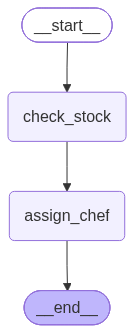

In [9]:
kitchen_subgraph

### Parent Graph (메인 홀 시스템)

In [10]:
# [부서 1] 메뉴 추천
def menu_recommender(state: ReservationState):
    last_msg = state["messages"][-1].content if state["messages"] else ""

    if "비싸" in last_msg or "부담" in last_msg:
        proposal = "B코스 (런치 스페셜)"
        price = 80000
        msg = f"🍣 부담 없는 '{proposal} ({price:,}원)'은 어떠신가요?"
    else:
        proposal = "A코스 (쉐프 오마카세)"
        price = 150000
        msg = f"🍣 시그니처 '{proposal} ({price:,}원)'를 추천합니다."

    return {"menu": proposal, "price": price, "messages": [msg]}

In [11]:
from typing import Literal
from pydantic import BaseModel, Field

class UserIntent(BaseModel):
    action: Literal["confirm", "change", "cancel"] = Field(description="확정, 변경, 취소 판단")

In [12]:
intent_analyzer = model.with_structured_output(UserIntent)

In [13]:
# [부서 2] Agentic Router
def customer_confirm_node(state: ReservationState):
    menu = state['menu']
    price = state['price']

    print(f"\n🛑 [System]: 고객 의사 확인 중 (Interrupt)")

    # 1. 멈추고 사람의 대답을 기다립니다.
    user_input = interrupt(f"'{menu}' ({price:,}원)으로 하시겠습니까?")
    print(f"▶️ [User Input]: \"{user_input}\"")

    # 2. LLM 의도 분석
    analysis = intent_analyzer.invoke(f"제안: {menu}, 답변: {user_input}")
    print(f"🧠 [AI Router]: 의도='{analysis.action}'")

    # 3. 분류된 의도에 따라 Command(goto=...)로 런타임 라우팅을 수행합니다.
    if analysis.action == "confirm":
        # [핵심] 여기서 'kitchen'으로 보내면, 노드가 아닌 연결된 Subgraph가 통째로 실행됩니다.
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="kitchen"
        )
    elif analysis.action == "change":
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="recommender"
        )
    else:
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="cancel"
        )

In [14]:
# [부서 3] 취소 처리
def cancel_node(state: ReservationState):
    print(f"\n👋 [카운터]: 예약 종료.")
    return {"status": "cancelled"}

In [15]:
parent_builder = StateGraph(ReservationState)

parent_builder.add_node("recommender", menu_recommender)
parent_builder.add_node("confirm", customer_confirm_node)
parent_builder.add_node("cancel", cancel_node)

In [16]:
# 컴파일된 Subgraph를 '노드'로 등록
# [핵심] 컴파일된 Subgraph를 '노드'로 등록합니다.
# 이름은 "kitchen"이지만, 실제로는 'kitchen_subgraph' 전체가 실행됩니다.
parent_builder.add_node("kitchen", kitchen_subgraph)



In [18]:
# 엣지 등록

# 최소한의 정적 엣지만 연결 (나머지는 Command goto가 동적으로 처리)
parent_builder.add_edge(START, "recommender")
parent_builder.add_edge("recommender", "confirm")
parent_builder.add_edge("kitchen", END) # 주방 작업이 끝나면 전체 프로세스 종료


In [19]:
checkpointer = InMemorySaver()

In [20]:
app = parent_builder.compile(checkpointer=checkpointer)

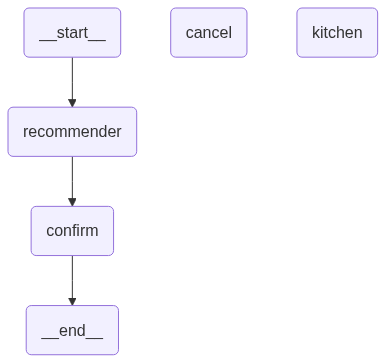

In [21]:
app

### 실행

In [22]:
config = {"configurable": {"thread_id": "subgraph-demo-1"}}

In [23]:
app.invoke({"messages": []}, config=config)


🛑 [System]: 고객 의사 확인 중 (Interrupt)


{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='d4513795-8dc3-475e-ae5d-aea710f43f65')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 '__interrupt__': [Interrupt(value="'A코스 (쉐프 오마카세)' (150,000원)으로 하시겠습니까?", id='32c21ead5fdcc55bc1ee26ff057bad77')]}

In [24]:
user_response = "좋아요, 그걸로 주세요."
result = app.invoke(Command(resume=user_response), config=config)


🛑 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "좋아요, 그걸로 주세요."
🧠 [AI Router]: 의도='confirm'

   🍳 [주방/재료팀] 'A코스 (쉐프 오마카세)' 재료 재고 확인 중...
   👨‍🍳 [주방/인사팀] Master Jiro 쉐프 배정 완료 (예상 소요: 40분)


In [25]:
result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='d4513795-8dc3-475e-ae5d-aea710f43f65'),
  HumanMessage(content='좋아요, 그걸로 주세요.', additional_kwargs={}, response_metadata={}, id='eb63ed9e-d763-4fca-8415-b58c639a426b')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 'status': 'cooking',
 'chef_name': 'Master Jiro',
 'cooking_time': '40분'}

In [26]:
print(f"메뉴: {result['menu']}")
print(f"상태: {result['status']}")
print(f"담당 쉐프: {result.get('chef_name')}")

메뉴: A코스 (쉐프 오마카세)
상태: cooking
담당 쉐프: Master Jiro


In [27]:
config = {"configurable": {"thread_id": "subgraph-demo-2"}}

In [28]:
app.invoke({"messages": []}, config=config)


🛑 [System]: 고객 의사 확인 중 (Interrupt)


{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='6f8d2539-9226-4a00-9db0-dd205b04926b')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 '__interrupt__': [Interrupt(value="'A코스 (쉐프 오마카세)' (150,000원)으로 하시겠습니까?", id='83105019b0586f63881a171aaab54770')]}

In [29]:
user_response = "아니요.. 너무 비싸요."
result = app.invoke(Command(resume=user_response), config=config)


🛑 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "아니요.. 너무 비싸요."
🧠 [AI Router]: 의도='change'

🛑 [System]: 고객 의사 확인 중 (Interrupt)


In [31]:
result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='6f8d2539-9226-4a00-9db0-dd205b04926b'),
  HumanMessage(content='아니요.. 너무 비싸요.', additional_kwargs={}, response_metadata={}, id='ce197465-34c4-4fd5-a127-c183291088a6'),
  HumanMessage(content="🍣 부담 없는 'B코스 (런치 스페셜) (80,000원)'은 어떠신가요?", additional_kwargs={}, response_metadata={}, id='143dfdce-3de4-4f2a-bd12-c9af46866369')],
 'menu': 'B코스 (런치 스페셜)',
 'price': 80000,
 '__interrupt__': [Interrupt(value="'B코스 (런치 스페셜)' (80,000원)으로 하시겠습니까?", id='41bda529da070e672131aea68408757e')]}

In [30]:
user_response = "그렇게 할게요."
final_result = app.invoke(Command(resume=user_response), config=config)


🛑 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "그렇게 할게요."
🧠 [AI Router]: 의도='confirm'

   🍳 [주방/재료팀] 'B코스 (런치 스페셜)' 재료 재고 확인 중...
   👨‍🍳 [주방/인사팀] Chef Kim 쉐프 배정 완료 (예상 소요: 20분)


In [32]:
final_result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='6f8d2539-9226-4a00-9db0-dd205b04926b'),
  HumanMessage(content='아니요.. 너무 비싸요.', additional_kwargs={}, response_metadata={}, id='ce197465-34c4-4fd5-a127-c183291088a6'),
  HumanMessage(content="🍣 부담 없는 'B코스 (런치 스페셜) (80,000원)'은 어떠신가요?", additional_kwargs={}, response_metadata={}, id='143dfdce-3de4-4f2a-bd12-c9af46866369'),
  HumanMessage(content='그렇게 할게요.', additional_kwargs={}, response_metadata={}, id='f8684bcc-243e-4ec9-9eea-269045926fba')],
 'menu': 'B코스 (런치 스페셜)',
 'price': 80000,
 'status': 'cooking',
 'chef_name': 'Chef Kim',
 'cooking_time': '20분'}

In [33]:
print(f"메뉴: {final_result['menu']}")
print(f"상태: {final_result['status']}")
print(f"담당 쉐프: {final_result.get('chef_name')} (Subgraph에서 생성된 정보!)")

메뉴: B코스 (런치 스페셜)
상태: cooking
담당 쉐프: Chef Kim (Subgraph에서 생성된 정보!)


# State 분리

## Child Graph

### State 정의

In [40]:
from typing_extensions import TypedDict

# 배송 모듈만의 완전히 독립적인 State
class DeliveryState(TypedDict):
    address: str
    package_info: str
    delivery_status: str


### Node 정의

In [41]:
def pickup_package(state: DeliveryState):
    print(f"\n   🛵 [배달업체] 픽업 완료! (물품: {state['package_info']})")
    return {"delivery_status": "picked_up"}

In [42]:
def deliver_to_customer(state: DeliveryState):
    print(f"   Hit [배달업체] {state['address']}로 배송 중... 띵동! 배달 완료.")
    return {"delivery_status": "delivered"}

### 그래프 생성

In [43]:
delivery_builder = StateGraph(DeliveryState)

delivery_builder.add_node("pickup", pickup_package)
delivery_builder.add_node("deliver", deliver_to_customer)

delivery_builder.add_edge(START, "pickup")
delivery_builder.add_edge("pickup", "deliver")
delivery_builder.add_edge("deliver", END)

In [44]:
# 하위 그래프 컴파일
delivery_graph = delivery_builder.compile()

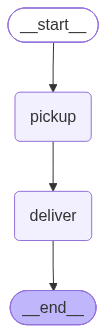

In [45]:
delivery_graph

## Parent Graph

### State 정의


In [46]:
class RestaurantState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    menu: str
    customer_address: str
    final_status: str

### Node 정의

In [47]:
def cook_food(state: RestaurantState):
    print(f"\n👨‍🍳 [주방] '{state['menu']}' 조리 완료! 포장했습니다.")
    return {"messages": ["조리 완료"]}

In [48]:
# 외부 그래프를 호출하는 '브릿지(Bridge)' 노드
def call_delivery_service(state):
    print("\n📞 [매니저] 배달 업체 호출 중...")

    # 1. 내 공책(Parent)의 정보를  -> 외부 업체 양식 (Child)로 변환 (Mapping)
    delivery_input = {
        "address": state["customer_address"],          
        "package_info": state["menu"],       
        "delivery_status": "pending"         
    }

    # 2. 함수 안에서 그래프를 실행 (API 호출하듯이)
    delivery_result = delivery_graph.invoke(delivery_input)

    # 3. 결과를 받아서 내 공책에 기록
    final_status = delivery_result['delivery_status']

    # 자식이 반환한 delivery_status를 부모의 status 키에 맞춰 업데이트합니다.
    return {"final_status": final_status }

### 그래프 생성

In [49]:
parent_builder = StateGraph(RestaurantState)

parent_builder.add_node("kitchen", cook_food)
parent_builder.add_node("delivery_manager", call_delivery_service)

parent_builder.add_edge(START, "kitchen")
parent_builder.add_edge("kitchen", "delivery_manager")
parent_builder.add_edge("delivery_manager", END)

In [50]:
app = parent_builder.compile()

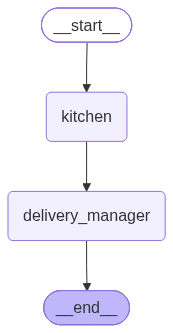

In [51]:
app

### 실행

In [52]:
inputs = {
    "menu": "특선 초밥 세트",
    "customer_address": "서울시 강남구 역삼동 123",
    "messages": []
}

In [53]:
result = app.invoke(inputs)


👨‍🍳 [주방] '특선 초밥 세트' 조리 완료! 포장했습니다.

📞 [매니저] 배달 업체 호출 중...

   🛵 [배달업체] 픽업 완료! (물품: 특선 초밥 세트)
   Hit [배달업체] 서울시 강남구 역삼동 123로 배송 중... 띵동! 배달 완료.


In [54]:
result

{'messages': [HumanMessage(content='조리 완료', additional_kwargs={}, response_metadata={}, id='f1d57fa2-8485-4465-8981-d30e50e891ce')],
 'menu': '특선 초밥 세트',
 'customer_address': '서울시 강남구 역삼동 123',
 'final_status': 'delivered'}

# Subgraph (실습)

# 📝 [실습 1] "여행용 환전 지갑" 만들기

### 배경: 당신은 여행 가이드 앱을 만들고 있습니다. 사용자가 "100달러 환전해줘"라고 말하면, 외부 은행 시스템(Subgraph)에 요청하여 환전을 처리해야 합니다.

### 제약 사항:
1. 여행 앱(Parent)과 은행(Child)은 서로 다른 보안 시스템을 쓰기 때문에 상태(State)를 공유하지 않습니다.

2. 따라서 add_node(subgraph)를 쓸 수 없고, 노드 함수 안에서 invoke()를 사용해야 합니다.

3. Parent State의 request_amount(요청 금액)를 Child State의 usd_amount(입금액)로 변환해서 넘겨줘야 합니다.

### ✅ 요구사항:

1. 빈칸으로 비워둔 exchange_bridge_node 함수를 완성하세요.

2. Parent의 request_amount 값을 읽어옵니다.

3. Child(bank_graph)를 invoke하여 환전을 수행합니다.

4. 결과로 받은 krw_result를 Parent의 balance_krw에 업데이트하세요.

In [ ]:
# @title
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# ==========================================
# 1. [Child] 외부 은행 시스템 (수정 금지)
# ==========================================
class BankState(TypedDict):
    usd_amount: int   # 입금된 달러
    krw_result: int   # 환전된 원화
    receipt: str      # 영수증

def calculate_exchange(state: BankState):
    rate = 1400 # 환율 1400원 가정
    krw = state['usd_amount'] * rate
    print(f"   🏦 [은행] ${state['usd_amount']} -> {krw}원 환전 처리 중...")
    return {
        "krw_result": krw,
        "receipt": f"[영수증] {state['usd_amount']} USD -> {krw} KRW"
    }

bank_builder = StateGraph(BankState)
bank_builder.add_node("calc", calculate_exchange)
bank_builder.add_edge(START, "calc")
bank_builder.add_edge("calc", END)
bank_graph = bank_builder.compile()

# ==========================================
# 2. [Parent] 여행 가이드 앱
# ==========================================
class TravelState(TypedDict):
    request_amount: int  # 사용자가 요청한 달러
    balance_krw: int     # 나의 원화 지갑 잔액
    status: str

# 사용자 요청을 처리하는 노드
def request_node(state: TravelState):
    amount = state['request_amount']
    print(f"\n✈️ [가이드] ${amount} 환전을 위해 은행에 연결합니다.")
    return {"status": "requesting"}

# ★ [미션] 여기가 문제입니다! ★
def exchange_bridge_node(state: TravelState):
    """
    1. Parent State에서 'request_amount'를 가져오세요.
    2. Bank State 양식({'usd_amount': ...})에 맞춰 데이터를 만드세요.
    3. bank_graph를 invoke() 하세요.
    4. 결과('krw_result')를 가져와서 Parent State의 'balance_krw'에 넣어서 반환하세요.
    """
    # (여기에 코드를 작성하세요)
    pass

# ==========================================
# 3. 그래프 조립 (수정 금지)
# ==========================================
app_builder = StateGraph(TravelState)
app_builder.add_node("guide", request_node)
app_builder.add_node("bank_bridge", exchange_bridge_node)

app_builder.add_edge(START, "guide")
app_builder.add_edge("guide", "bank_bridge")
app_builder.add_edge("bank_bridge", END)

app = app_builder.compile()

# 실행
print("### 환전 요청 실행 ###")
result = app.invoke({"request_amount": 100, "balance_krw": 0, "status": "start"})

print(f"\n🎉 [최종 결과] 내 지갑 잔액: {result['balance_krw']}원")

In [ ]:
# @title
# ★ [정답] ★
def exchange_bridge_node(state: TravelState):
    # 1. 내 공책(Parent)에서 정보 꺼내기
    my_request = state['request_amount']

    # 2. 외부 업체 공책(Child) 양식에 맞춰 데이터 포장 (Mapping)
    # Parent의 'request_amount' -> Child의 'usd_amount'
    bank_input = {"usd_amount": my_request}

    # 3. 외부 그래프 호출 (Invoke)
    # invoke()를 쓰면 해당 그래프가 독립적으로 실행되고 결과만 리턴됩니다.
    bank_output = bank_graph.invoke(bank_input)

    # 4. 결과를 받아서 내 공책에 기록
    # Child의 'krw_result' -> Parent의 'balance_krw'
    exchanged_money = bank_output["krw_result"]
    print(f"✈️ [가이드] 은행에서 {exchanged_money}원을 받아왔습니다.")

    return {
        "balance_krw": exchanged_money,
        "status": "completed"
    }

# 📝 [실습 2] AI 뉴스레터 편집국

목표: 주제만 던지면 기획, 검색, 작성, 그리고 **인간 편집장의 검수(Review)**까지 거쳐 최종 원고를 발행하는 시스템 구축.

## 📋 프로젝트 명세서 (Requirements)
여러분이 구현해야 할 시스템의 요구사항은 다음과 같습니다.

### 구조 (Architecture):

- Parent Graph (편집국): 전체 흐름을 관장하며, **인간 편집장(Human)**과의 소통을 담당합니다.

- Subgraph (제작팀): **검색(Researcher)**과 **집필(Writer)**을 담당하는 에이전트들이 모여 있습니다.

### 워크플로우 (Workflow):

1. 사용자가 주제(Topic)를 입력합니다.

2. **제작팀(Subgraph)**이 작동하여 초안을 작성합니다.

3. **편집장(Parent)**에게 Interrupt가 걸립니다. 초안을 보여주고 승인을 요청합니다.

4. 승인(Approve) 시: 최종 발행하고 종료합니다.

5. 거절(Reject) 시: 피드백(Feedback)을 입력받아 다시 제작팀(Subgraph)으로 돌려보냅니다. (Command 사용)

6. 수정(Revision): 제작팀은 피드백을 반영하여 원고를 수정합니다. (State 유지)

In [ ]:
# @title
from typing import Annotated, TypedDict, List, Literal, Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

# ====================================================
# 1. State 정의 (Shared State)
# ====================================================
class NewsState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    topic: str
    research_data: Optional[str]
    draft: Optional[str]
    feedback: Optional[str]
    status: str

# [요청하신 모델 적용]
# 실제 실행 시 API Key가 필요하며, gpt-5-nano가 없다면 gpt-4o-mini 등으로 대체될 수 있습니다.
llm = ChatOpenAI(model="gpt-5-nano", temperature=0.7)

# ====================================================
# 2. [Subgraph] 콘텐츠 제작팀 (Real AI 적용)
# ====================================================

def researcher_node(state: NewsState):
    topic = state["topic"]
    feedback = state.get("feedback")

    print(f"\n🔎 [Researcher] AI가 '{topic}' 자료를 조사하고 있습니다...")

    # 1. 피드백 유무에 따른 프롬프트 구성
    if feedback:
        query = f"주제: '{topic}'\n추가 지시사항(피드백): {feedback}\n\n위 내용을 반영하여 핵심 정보를 조사하세요."
        print(f"   ↳ (지시사항 반영 중: {feedback})")
    else:
        query = f"주제: '{topic}'\n\n위 주제에 대한 최신 트렌드와 핵심 사실 3가지를 요약해서 조사하세요."

    # 2. LLM 호출 (Real Generation)
    response = llm.invoke([
        SystemMessage(content="당신은 세계 최고의 IT 트렌드 리서처입니다. 팩트 기반으로 명확하게 요약하세요."),
        HumanMessage(content=query)
    ])

    return {"research_data": response.content}

def writer_node(state: NewsState):
    print(f"\n✍️ [Writer] AI가 뉴스레터 초안을 작성하고 있습니다...")

    data = state["research_data"]
    feedback = state.get("feedback")

    # 1. 프롬프트 구성
    if feedback:
        prompt = f"""
        [지시사항]
        편집장의 피드백: "{feedback}"

        위 피드백을 철저히 반영하여, 아래 조사 자료를 바탕으로 뉴스레터를 '다시' 작성하세요.

        [조사 자료]
        {data}
        """
    else:
        prompt = f"""
        [지시사항]
        아래 조사 자료를 바탕으로 독자들이 흥미를 느낄만한 뉴스레터 초안을 작성하세요.
        서론-본론-결론 구조를 갖추세요.

        [조사 자료]
        {data}
        """

    # 2. LLM 호출
    response = llm.invoke([
        SystemMessage(content="당신은 베스트셀러 작가이자 뉴스레터 에디터입니다. 전문적이면서도 읽기 쉬운 톤을 유지하세요."),
        HumanMessage(content=prompt)
    ])

    return {"draft": response.content}

# Subgraph 조립
content_builder = StateGraph(NewsState)
content_builder.add_node("researcher", researcher_node)
content_builder.add_node("writer", writer_node)

content_builder.add_edge(START, "researcher")
content_builder.add_edge("researcher", "writer")
content_builder.add_edge("writer", END)

content_team = content_builder.compile()

# ====================================================
# 3. [Parent Graph] 편집국 (Human-in-the-loop)
# ====================================================

def human_review_node(state: NewsState):
    current_draft = state["draft"]

    print(f"\n🛑 [Editor-in-Chief] 초안 검수 (Interrupt)")
    print("=" * 60)
    print(f"[AI가 작성한 초안]\n\n{current_draft}")
    print("=" * 60)

    # 인간의 개입
    review_input = interrupt("승인하려면 'ok', 수정하려면 '피드백'을 입력하세요.")

    print(f"▶️ [Editor Decision]: {review_input}")

    # 라우팅
    if review_input.lower() in ["ok", "승인", "yes"]:
        return Command(
            update={
                "status": "published",
                "messages": [HumanMessage(content="편집장 승인 완료")]
            },
            goto="publisher"
        )
    else:
        return Command(
            update={
                "feedback": review_input,
                "messages": [HumanMessage(content=f"피드백: {review_input}")]
            },
            goto="content_team" # 다시 Subgraph로 보냄
        )

def publisher_node(state: NewsState):
    print(f"\n🚀 [Publisher] 뉴스레터 발행 완료! (구독자에게 전송됨)")
    return {"status": "completed"}

# Parent Graph 조립
parent_builder = StateGraph(NewsState)

parent_builder.add_node("content_team", content_team) # Subgraph를 노드로!
parent_builder.add_node("reviewer", human_review_node)
parent_builder.add_node("publisher", publisher_node)

parent_builder.add_edge(START, "content_team")
parent_builder.add_edge("content_team", "reviewer")
parent_builder.add_edge("publisher", END)

checkpointer = InMemorySaver()
app = parent_builder.compile(checkpointer=checkpointer)

In [ ]:
config = {"configurable": {"thread_id": "newsletter-prod-1"}}

app.invoke({"topic": "2025년 생성형 AI 트렌드"}, config=config)


🔎 [Researcher] AI가 '2025년 생성형 AI 트렌드' 자료를 조사하고 있습니다...

✍️ [Writer] AI가 뉴스레터 초안을 작성하고 있습니다...

🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

제목: 2025년 생성형 AI 트렌드 3대 축과 실무 로드맵

서론
AI의 속도에 발맞추려면 기술 그 자체보다 먼저 검토해야 할 것이 있습니다. 바로 거버넌스의 표준화, 멀티모달 코파일럿의 생산성 도구화, 그리고 엣지/오픈소스 중심의 데이터 주권 강화입니다. 오늘의 뉴스레터는 이 세 가지 축을 바탕으로, 기업이 안전하고 효과적으로 AI를 도입하고 운영하는 데 필요한 실무 가이드와 우선순위를 제시합니다. 각 축은 서로를 보완하며, 단계적으로 도입할 때 가장 큰 ROI를 기대할 수 있습니다.

본론
핵심 사실 1. 엔터프라이즈 거버넌스와 컴플라이언스의 표준화 가속
- 요지: 기업이 생성형 AI를 안정적으로 활용하기 위한 거버넌스 체계가 표준화되고 있습니다.
- 구체 내용 요약: 데이터 소스 추적, 정책 기반 프롬프트 거버넌스, 자동 위험 평가 및 감사 로깅이 기본 구성요소로 자리잡습니다.
- 기대 효과: 데이터 사용 규정 준수 강화, 안전성 향상, 감사 가능성 증가로 기업 신뢰도와 ROI 상승.
- 실무 시사점(우선 검토 항목): 데이터 거버넌스 정책 수립, 로깅/감사 체계 구축, 프롬프트 관리 자동화 도구 도입을 먼저 고려하세요.
- 적용 팁: 기업 내 데이터 출처를 한눈에 추적할 수 있는 기록 체계와, 프롬프트 정책의 버전 관리 프로세스를 빠르게 시도해 보십시오.

핵심 사실 2. 멀티모달 코파일럿의 생산성 도구화 확산
- 요지: 텍스트, 이미지, 음성, 코드, 비디오를 한꺼번에 다루는 멀티모달 모델이 생산성 도구의 핵심 코파일럿으로 확산됩니다.
- 구체 내용 요약: 디자인, 마케팅, 소프트웨어 개발, 고객지원 등 다양한 업무 흐름에서 멀티모달 입력/출력을 활용한 자동 생성·요약·전환이 통합된 워크플

{'messages': [],
 'topic': '2025년 생성형 AI 트렌드',
 'research_data': '다음은 2025년 생성형 AI 트렌드에 대한 최신 관찰과 예측을 바탕으로 정리한 3가지 핵심 사실입니다.\n\n- 핵심 사실 1: 엔터프라이즈 거버넌스와 컴플라이언스의 표준화 가속\n  - 요지: 기업에서 생성형 AI를 업무에 안정적으로 도입하기 위한 거버넌스 체계가 표준화되고 있습니다.\n  - 구체 내용: 데이터 소스 추적, 프롬프트 거버넌스(정책 기반 관리), 자동 위험 평가 및 감사 로깅 기능이 기업용 AI 플랫폼의 기본 구성요소로 자리잡습니다.\n  - 기대 효과: 데이터 사용 규정 준수, 안전성 강화, 감사 가능성 향상으로 기업 신뢰도와 ROI 상승에 기여합니다.\n  - 실무 시사점: 데이터 거버넌스 정책 수립과 로깅/감사 체계 구축, 프롬프트 관리 자동화 도구 도입을 우선 검토하세요.\n\n- 핵심 사실 2: 멀티모달 코파일럿의 생산성 도구화 확산\n  - 요지: 텍스트, 이미지, 음성, 코드, 비디오를 한꺼번에 다루는 멀티모달 모델이 기업 생산성 도구의 핵심 코파일럿으로 보급될 가능성이 큽니다.\n  - 구체 내용: 디자인, 마케팅, 소프트웨어 개발, 고객지원 등 다양한 업무 흐름에서 멀티모달 특성을 활용한 자동 생성·요약·전환 작업이 통합된 워크플로우를 지원합니다.\n  - 기대 효과: 창의적 생산성 향상, 컨텍스트 간 전환의 효율성 증가, 반복 작업의 자동화로 인한 운영비용 절감.\n  - 실무 시사점: 멀티모달 입력/출력 파이프라인을 기존 도구에 연결하고, 코파일럿 기반의 업무 프로세스 개선을 우선 시도해 보세요.\n\n- 핵심 사실 3: 엣지/오픈소스 중심의 경량화 및 데이터 주권 강화\n  - 요지: 데이터 프라이버시와 비용 효율성 요구가 커지면서 로컬 처리와 오프-클라우드 배포를 지원하는 경량 모델의 채택이 늘고 있습니다.\n  - 구체 내용: 경량화된 파인튜닝 가능 모델, 양방향은 하이브리드 배포, 엣지 디바이스에서

In [ ]:
snapshot = app.get_state(config)
print(f"\n⚠️ 현재 단계: {snapshot.next}")

In [ ]:
feedback_msg = "너무 딱딱해요. 좀 더 유머러스하고 친근한 말투로 바꿔주세요."

app.invoke(Command(resume=feedback_msg), config=config)


🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

제목: 2025년 생성형 AI 트렌드 3대 축과 실무 로드맵

서론
AI의 속도에 발맞추려면 기술 그 자체보다 먼저 검토해야 할 것이 있습니다. 바로 거버넌스의 표준화, 멀티모달 코파일럿의 생산성 도구화, 그리고 엣지/오픈소스 중심의 데이터 주권 강화입니다. 오늘의 뉴스레터는 이 세 가지 축을 바탕으로, 기업이 안전하고 효과적으로 AI를 도입하고 운영하는 데 필요한 실무 가이드와 우선순위를 제시합니다. 각 축은 서로를 보완하며, 단계적으로 도입할 때 가장 큰 ROI를 기대할 수 있습니다.

본론
핵심 사실 1. 엔터프라이즈 거버넌스와 컴플라이언스의 표준화 가속
- 요지: 기업이 생성형 AI를 안정적으로 활용하기 위한 거버넌스 체계가 표준화되고 있습니다.
- 구체 내용 요약: 데이터 소스 추적, 정책 기반 프롬프트 거버넌스, 자동 위험 평가 및 감사 로깅이 기본 구성요소로 자리잡습니다.
- 기대 효과: 데이터 사용 규정 준수 강화, 안전성 향상, 감사 가능성 증가로 기업 신뢰도와 ROI 상승.
- 실무 시사점(우선 검토 항목): 데이터 거버넌스 정책 수립, 로깅/감사 체계 구축, 프롬프트 관리 자동화 도구 도입을 먼저 고려하세요.
- 적용 팁: 기업 내 데이터 출처를 한눈에 추적할 수 있는 기록 체계와, 프롬프트 정책의 버전 관리 프로세스를 빠르게 시도해 보십시오.

핵심 사실 2. 멀티모달 코파일럿의 생산성 도구화 확산
- 요지: 텍스트, 이미지, 음성, 코드, 비디오를 한꺼번에 다루는 멀티모달 모델이 생산성 도구의 핵심 코파일럿으로 확산됩니다.
- 구체 내용 요약: 디자인, 마케팅, 소프트웨어 개발, 고객지원 등 다양한 업무 흐름에서 멀티모달 입력/출력을 활용한 자동 생성·요약·전환이 통합된 워크플로우를 지원합니다.
- 기대 효과: 창의적 생산성 증가, 컨텍스트 간 전환의 효율성 증가, 반복 작업의 자동화로 운영비용 절감.
- 실무 시사점(우선 시도 포인트): 멀티

{'messages': [HumanMessage(content='피드백: 너무 딱딱해요. 좀 더 유머러스하고 친근한 말투로 바꿔주세요.', additional_kwargs={}, response_metadata={}, id='eac8f305-b70a-4045-9b90-99011859d0a4')],
 'topic': '2025년 생성형 AI 트렌드',
 'research_data': "좋아요! 2025년 생성형 AI 트렌드를 팩트 중심으로, 그런데 조금 친근하고 유머 섞인 톤으로 정리해볼게요.\n\n주요 핵심 포인트 10가지\n\n1) 멀티모달의 일반화\n- 한 모델이 텍스트+이미지+음성+코드+데이터까지 한꺼번에 다룬다. 대화 중에 사진을 분석하고, 디자인 피드백은 즉시 그림으로 보여주는 식.\n- 비즈니스 포인트: 콘텐츠 생산 속도↑, 사용자 편의성 대폭 향상.\n\n2) AI 코파일럿의 보편화\n- 개발자, 디자이너, 마케터 등 다양한 직군의 '삐딱한 친구'가 돼주는 코파일럿이 대세. IDE에서 코드 제안, 문서 초안 작성, 데이터 분석까지 도와줌.\n- 비즈니스 포인트: 시간 절약과 오류 감소.\n\n3) 에이전트 기반 자동화의 상용화\n- AI가 일을 스스로 기획하고 실행하는 에이전트가 워크플로를 연결. 예를 들면 데이터 파이프라인 설계→실행→결과 보고까지 한 번에 처리.\n- 비즈니스 포인트: 반복 업무 최소화, 운영 효율 증대.\n\n4) 합성 데이터와 데이터 프라이버시 중심 전략\n- 실데이터 대신 합성 데이터를 많이 활용하고, 차등 프라이버시나 데이터 라이센스 관리와 함께 운용.\n- 비즈니스 포인트: 개인정보 규정 준수와 데이터 편향 관리가 쉬워짐.\n\n5) 엣지/온디바이스 실행의 확대\n- 네트워크 연결이 없어도 동작하고, 지연도 낮추고, 프라이버시도 보호하는 방향으로 강화.\n- 비즈니스 포인트: 모바일/현장 사용 사례에서의 신뢰성 높임.\n\n6) 효율성과 친환경 AI\n- 모델 경량화, 양자화, 희소화(sparsity) 등으로 비용과 에

In [ ]:
result = app.invoke(Command(resume="ok"), config=config)


🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

안녕하세요, 팀 여러분! 오늘은 2025년 생성형 AI 트렌드를 팩트는 팩트대로, 분위기는 살짝 친근하게 풀어봤어요. 딱딱한 용어는 닫아두고, 현장에서 바로 써먹을 포인트 위주로 정리했습니다. 자, 시작합니다.

1) 멀티모달의 일반화
- 한 모델이 텍스트, 이미지, 음성, 코드, 데이터까지 한꺼번에 다룬다. 대화 중 사진 분석하고, 디자인 피드백은 즉시 그림으로 보여주는 식.
- 비즈니스 포인트: 콘텐츠 생산 속도가 빨라지고, 사용자가 체감하는 편의성 대폭 상승.

2) AI 코파일럿의 보편화
- 개발자·디자이너·마케터 등 다양한 직군의 ‘삐딱한 친구’가 되어주는 코파일럿이 대세. IDE에서 코드 제안, 문서 초안 작성, 데이터 분석까지 도와줌.
- 비즈니스 포인트: 시간 절약과 오류 감소로 팀의 생산력 상승.

3) 에이전트 기반 자동화의 상용화
- AI가 일을 스스로 기획하고 실행하는 에이전트가 워크플로를 연결. 데이터 파이프라인 설계→실행→결과 보고까지 한 번에 처리.
- 비즈니스 포인트: 반복 업무 최소화, 운영 효율 대폭 개선.

4) 합성 데이터와 데이터 프라이버시 중심 전략
- 실데이터 대신 합성 데이터를 많이 활용하고, 차등 프라이버시나 데이터 라이선스 관리와 함께 운용.
- 비즈니스 포인트: 개인정보 규정 준수와 데이터 편향 관리가 쉬워짐.

5) 엣지/온디바이스 실행의 확대
- 네트워크 연결이 없어도 작동하고, 지연도 낮추고, 프라이버시도 보호하는 방향으로 강화.
- 비즈니스 포인트: 모바일/현장 사용 사례에서의 신뢰성 증가.

6) 효율성과 친환경 AI
- 모델 경량화, 양자화, 희소화(sparsity) 등으로 비용과 에너지 소비를 줄이는 기술이 표준으로 자리 잡음.
- 비즈니스 포인트: TCO 절감과 함께 그린 AI 이미지도 함께 향상.

7) 안전성, 거버넌스, 규제 대응 강화
- 평가 도구, 모델 카드 및 안전 가드레일, 워터마킹 등 투명성